In [1]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ── CONFIGURACIÓN ─────────────────────────────────────────────────────────────
BUITRE = "T10"
RUTA_CSV = f"datos_buitre/AviFauna_Muladares/{BUITRE}.csv"
# ── CARGA Y PREPROCESAMIENTO (idéntico al código LSTM) ────────────────────────
df = pd.read_csv(RUTA_CSV, low_memory=False)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df['altura_relativa'] = (df['height-above-sea'] - df['height-terrain']).clip(lower=0)
df = df[['timestamp', 'location-lat', 'location-long', 'altura_relativa']]
df = df.set_index('timestamp')
df = df[df['altura_relativa'] <= 3000]
df_resampled = df.resample('10min').mean().interpolate()


─── Latitud ────────────────────────────
  Paso 0/7388...
  Paso 25/7388...
  Paso 50/7388...
  Paso 75/7388...
  Paso 100/7388...
  Paso 125/7388...
  Paso 150/7388...
  Paso 175/7388...
  Paso 200/7388...
  Paso 225/7388...
  Paso 250/7388...
  Paso 275/7388...
  Paso 300/7388...
  Paso 325/7388...
  Paso 350/7388...
  Paso 375/7388...
  Paso 400/7388...
  Paso 425/7388...
  Paso 450/7388...
  Paso 475/7388...
  Paso 500/7388...
  Paso 525/7388...
  Paso 550/7388...
  Paso 575/7388...
  Paso 600/7388...
  Paso 625/7388...
  Paso 650/7388...
  Paso 675/7388...
  Paso 700/7388...
  Paso 725/7388...
  Paso 750/7388...
  Paso 775/7388...
  Paso 800/7388...
  Paso 825/7388...
  Paso 850/7388...
  Paso 875/7388...
  Paso 900/7388...
  Paso 925/7388...
  Paso 950/7388...
  Paso 975/7388...
  Paso 1000/7388...
  Paso 1025/7388...
  Paso 1050/7388...
  Paso 1075/7388...
  Paso 1100/7388...
  Paso 1125/7388...
  Paso 1150/7388...
  Paso 1175/7388...
  Paso 1200/7388...
  Paso 1225/7388...
  P

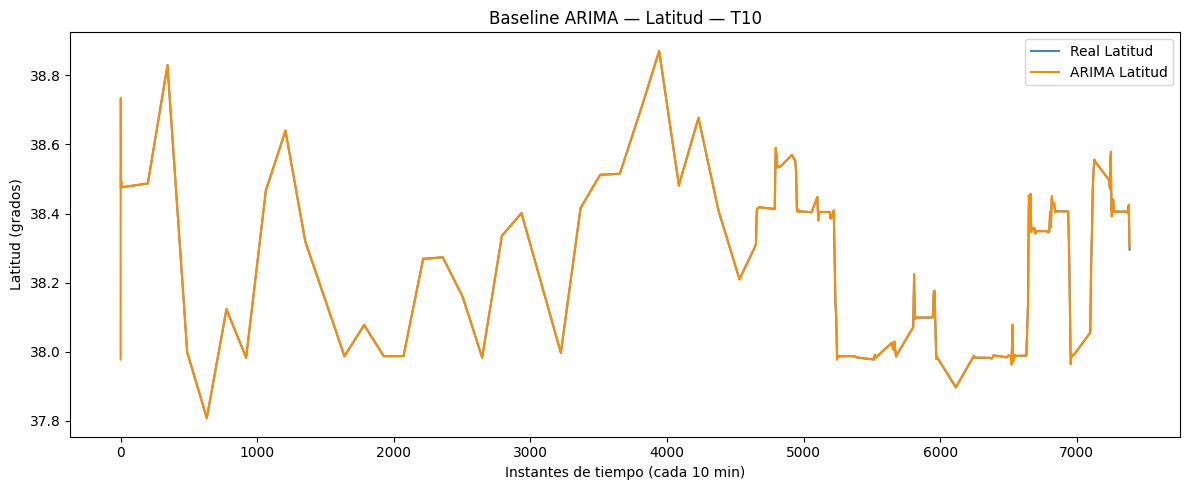


─── Longitud ────────────────────────────
  Paso 0/7388...
  Paso 25/7388...
  Paso 50/7388...
  Paso 75/7388...
  Paso 100/7388...
  Paso 125/7388...
  Paso 150/7388...
  Paso 175/7388...
  Paso 200/7388...
  Paso 225/7388...
  Paso 250/7388...
  Paso 275/7388...
  Paso 300/7388...
  Paso 325/7388...
  Paso 350/7388...
  Paso 375/7388...
  Paso 400/7388...
  Paso 425/7388...
  Paso 450/7388...
  Paso 475/7388...
  Paso 500/7388...
  Paso 525/7388...
  Paso 550/7388...
  Paso 575/7388...
  Paso 600/7388...
  Paso 625/7388...
  Paso 650/7388...
  Paso 675/7388...
  Paso 700/7388...
  Paso 725/7388...
  Paso 750/7388...
  Paso 775/7388...
  Paso 800/7388...
  Paso 825/7388...
  Paso 850/7388...
  Paso 875/7388...
  Paso 900/7388...
  Paso 925/7388...
  Paso 950/7388...
  Paso 975/7388...
  Paso 1000/7388...
  Paso 1025/7388...
  Paso 1050/7388...
  Paso 1075/7388...
  Paso 1100/7388...
  Paso 1125/7388...
  Paso 1150/7388...
  Paso 1175/7388...
  Paso 1200/7388...
  Paso 1225/7388...
  

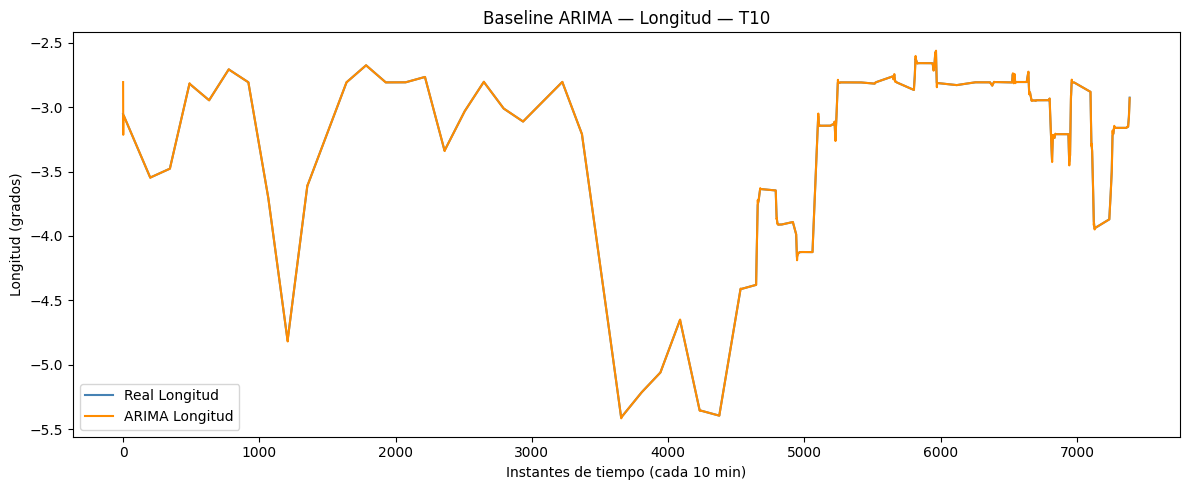


─── Altura relativa ────────────────────────────
  Paso 0/7388...
  Paso 25/7388...
  Paso 50/7388...
  Paso 75/7388...
  Paso 100/7388...
  Paso 125/7388...
  Paso 150/7388...
  Paso 175/7388...
  Paso 200/7388...
  Paso 225/7388...
  Paso 250/7388...
  Paso 275/7388...
  Paso 300/7388...
  Paso 325/7388...
  Paso 350/7388...
  Paso 375/7388...
  Paso 400/7388...
  Paso 425/7388...
  Paso 450/7388...
  Paso 475/7388...
  Paso 500/7388...
  Paso 525/7388...
  Paso 550/7388...
  Paso 575/7388...
  Paso 600/7388...
  Paso 625/7388...
  Paso 650/7388...
  Paso 675/7388...
  Paso 700/7388...
  Paso 725/7388...
  Paso 750/7388...
  Paso 775/7388...
  Paso 800/7388...
  Paso 825/7388...
  Paso 850/7388...
  Paso 875/7388...
  Paso 900/7388...
  Paso 925/7388...
  Paso 950/7388...
  Paso 975/7388...
  Paso 1000/7388...
  Paso 1025/7388...
  Paso 1050/7388...
  Paso 1075/7388...
  Paso 1100/7388...
  Paso 1125/7388...
  Paso 1150/7388...
  Paso 1175/7388...
  Paso 1200/7388...
  Paso 1225/738

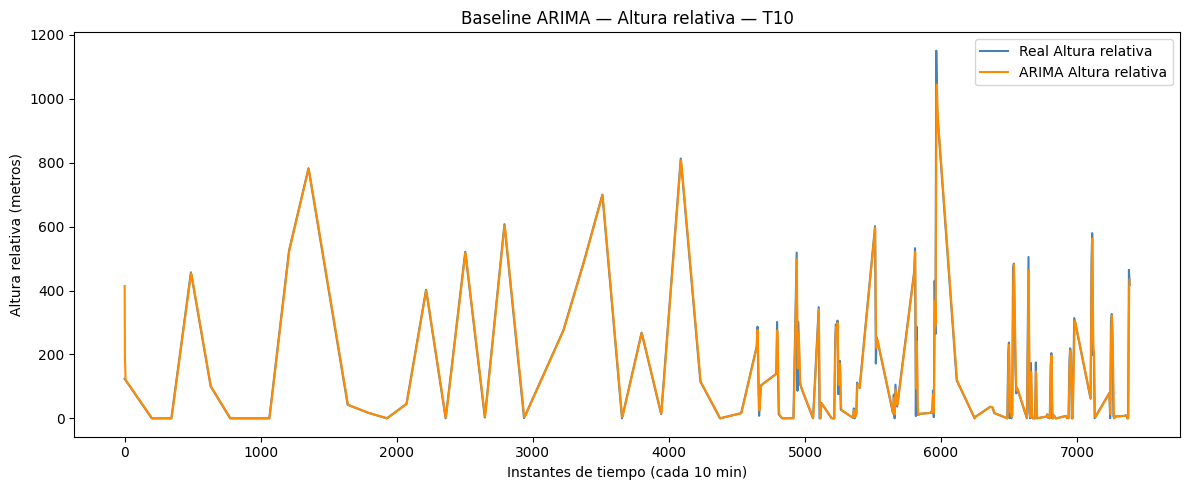

In [3]:
# ── DIVISIÓN (idéntica al código LSTM) ────────────────────────────────────────
n = len(df_resampled)
train_end  = int(n * 0.70)
test_start = int(n * 0.85)
N_TEST = n - test_start
variables = ['location-lat', 'location-long', 'altura_relativa']
nombres   = ['Latitud', 'Longitud', 'Altura relativa']
unidades  = ['grados', 'grados', 'metros']

resultados_arima = {}
import time

for var, nombre, unidad in zip(variables, nombres, unidades):
    print(f"\n─── {nombre} ────────────────────────────")
    start = time.time()
    serie       = df_resampled[var].values
    serie_train = serie[:train_end]
    serie_test  = serie[test_start:test_start + N_TEST]

    # Ajuste inicial del modelo sobre datos de entrenamiento
    modelo    = ARIMA(serie_train, order=(5, 1, 0))
    resultado = modelo.fit()

    predicciones = []

    for i in range(N_TEST):
        if i % 25 == 0:
            print(f"  Paso {i}/{N_TEST}...")
        # Predice un paso sin reajustar desde cero
        pred = resultado.forecast(steps=1)[0]
        predicciones.append(pred)
        # Actualiza el modelo con el valor real sin reajustar completamente
        resultado = resultado.append([serie_test[i]], refit=False)
    
    end = time.time()
    print(f"  Tiempo: {(end-start)/60:.1f} minutos")

    predicciones = np.array(predicciones)

    mae  = mean_absolute_error(serie_test, predicciones)
    rmse = np.sqrt(mean_squared_error(serie_test, predicciones))

    print(f"  MAE:  {mae:.4f} {unidad}")
    print(f"  RMSE: {rmse:.4f} {unidad}")

    resultados_arima[nombre] = {
        'real':   serie_test,
        'pred':   predicciones,
        'mae':    mae,
        'rmse':   rmse,
        'unidad': unidad
    }

    plt.figure(figsize=(12, 5))
    plt.plot(serie_test,   label=f"Real {nombre}",  color='steelblue')
    plt.plot(predicciones, label=f"ARIMA {nombre}", color='darkorange')
    plt.title(f"Baseline ARIMA — {nombre} — {BUITRE}")
    plt.xlabel("Instantes de tiempo (cada 10 min)")
    plt.ylabel(f"{nombre} ({unidad})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"Grafs/arima_{nombre.lower().replace(' ', '_')}_{BUITRE}.png")
    plt.show()

In [1]:
# ── MÉTRICAS LSTM SOBRE LOS MISMOS 100 PUNTOS ────────────────────────────────
# Pega aquí los valores que obtengas del código LSTM sobre los primeros 100 puntos
lstm_100= {
    'Latitud':         {'mae': 0.0014, 'rmse': 0.0026},  # sustituir con valores reales
    'Longitud':        {'mae': 0.0055, 'rmse': 0.0069},  # sustituir con valores reales
    'Altura relativa': {'mae': 25.34,   'rmse': 32.52},    # sustituir con valores reales
}

In [2]:
# ── TABLA COMPARATIVA ─────────────────────────────────────────────────────────
print("\n─── COMPARATIVA LSTM vs ARIMA (100 primeros puntos del test) ────────")
print(f"{'Variable':<20} {'MAE LSTM':>12} {'MAE ARIMA':>12} {'RMSE LSTM':>12} {'RMSE ARIMA':>12}")
print("─" * 70)
for nombre in lstm_100:
    if nombre in resultados_arima:
        print(f"{nombre:<20} "
              f"{lstm_100[nombre]['mae']:>12.4f} "
              f"{resultados_arima[nombre]['mae']:>12.4f} "
              f"{lstm_100[nombre]['rmse']:>12.4f} "
              f"{resultados_arima[nombre]['rmse']:>12.4f}")


─── COMPARATIVA LSTM vs ARIMA (100 primeros puntos del test) ────────
Variable                 MAE LSTM    MAE ARIMA    RMSE LSTM   RMSE ARIMA
──────────────────────────────────────────────────────────────────────


NameError: name 'resultados_arima' is not defined